In [5]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import BayesianRidge
from numpy import log10 as log
import geopandas as gpd
import sys
from pathlib import Path

current_path = Path.cwd().resolve()
PROJECT_ROOT = next((p for p in [current_path, *current_path.parents] if (p / "Scripts").is_dir()), None)

if PROJECT_ROOT is None:
    raise FileNotFoundError("Run this notebook from within the repository.")

scripts_directory = PROJECT_ROOT / "Scripts" / "Helpers"

if str(scripts_directory) not in sys.path:
    sys.path.append(str(scripts_directory))

from Helpers import *

In [7]:
plt.rcParams.update({
    'axes.titlesize': 20,      # plot titles
    'axes.labelsize': 22,      # x and y labels
    'xtick.labelsize': 22,     # x-axis tick labels
    'ytick.labelsize': 22,     # y-axis tick labels
    'legend.fontsize': 24,
    "font.family":"arial",
    #"font.serif": ["Computer Modern Roman"],
    "mathtext.fontset": "cm",
    "mathtext.default": "rm",
    "mathtext.rm"  : "arial",# legend
})

382
380
382


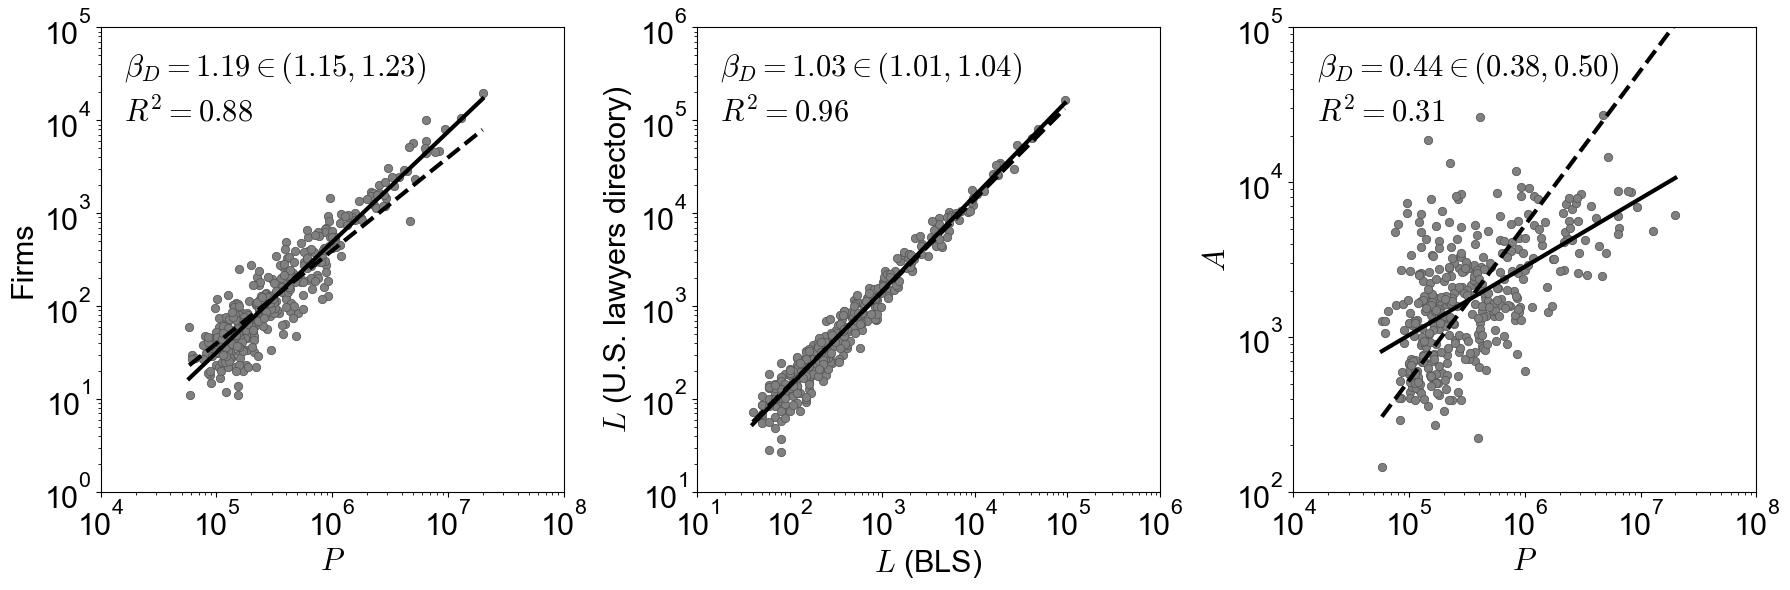

In [9]:
df = pd.read_csv(PROJECT_ROOT/"Data/Processed Data/sanity_check_data.csv")

y_firms_data = df["Firms"].values
x_firms_data = df["Population"].values
y_firms_label = "Firms"
x_firms_label = r"$\it{P}$"

y_emp_data = df["lawyers_in_firms"].values
x_emp_data = df["TOT_EMP"].values
y_emp_label = r"$\it{L}$ (U.S. lawyers directory)"
x_emp_label = r"$\it{L}$ (BLS)"

df_AN = pd.read_csv(PROJECT_ROOT/"Data/BrightData_Lawyers/BrightData_Lawyers_master.csv")
df_AN["MSA Code"] = (pd.to_numeric(df_AN["CBSA"], errors="coerce") // 10).astype("Int64")

gdf = gpd.read_file(PROJECT_ROOT/"Data/Geography/CBSA_shapefile_2025/tl_2025_us_cbsa.shp")[["GEOID", "NAMELSAD", "ALAND"]]
gdf = gdf[gdf["NAMELSAD"].str.contains("Metro Area", na=False)]
gdf["MSA Code"] = gdf["GEOID"].str[:-1].astype(int)
gdf["land_area_sqmi"] = gdf["ALAND"] / 2589988.110336

df_bls = pd.read_csv(PROJECT_ROOT/"Data/Population Data/MSA Population/ACSDT1Y2024.B01003-Data.csv")[["GEO_ID", "NAME", "B01003_001E"]]
df_bls = df_bls[df_bls["NAME"].str.contains("Metro Area", na=False)]
df_bls["MSA Code"] = df_bls["GEO_ID"].str[-5:].str[:-1].astype(int)

df_AN = df_AN.merge(df_bls[["MSA Code", "B01003_001E"]], on="MSA Code", how="left")
df_AN = df_AN.merge(gdf[["MSA Code", "land_area_sqmi"]], on="MSA Code", how="left")
df_AN[["B01003_001E", "land_area_sqmi"]] = df_AN[["B01003_001E", "land_area_sqmi"]].apply(pd.to_numeric, errors="coerce")
df_AN = df_AN.dropna(subset=["B01003_001E", "land_area_sqmi"])

y_data = df_AN["land_area_sqmi"].values
x_data = df_AN["B01003_001E"].values
y_label = r"$\it{A}$"
x_label = r"$\it{P}$"


colors = ["gray", "gray", "gray"]

datasets = [
    (x_firms_data, y_firms_data, x_firms_label, y_firms_label),
    (x_emp_data, y_emp_data, x_emp_label, y_emp_label),
    (x_data, y_data, x_label, y_label),
]

# (xmin_exp, xmax_exp, ymin_exp, ymax_exp) for each subplot
limits = [
    (4, 8, 0, 5),
    (1, 6, 1, 6),
    (4, 8, 2, 5)
]


fig, axes = plt.subplots(1, 3, figsize=(18, 6))
axes = axes.ravel()

for ax, (data, color, lim) in zip(axes, zip(datasets, colors, limits)):
    x, y, xlab, ylab = data
    plot_panel(ax, x, y, xlab, ylab, color, lim)

plt.tight_layout()
# Define the output directory and ensure it exists
save_dir = PROJECT_ROOT / "Figures/Supplementary Figure 8"
save_dir.mkdir(parents=True, exist_ok=True)
plt.savefig(save_dir / "Supplementary_Figure_8.pdf", bbox_inches='tight')
plt.show()